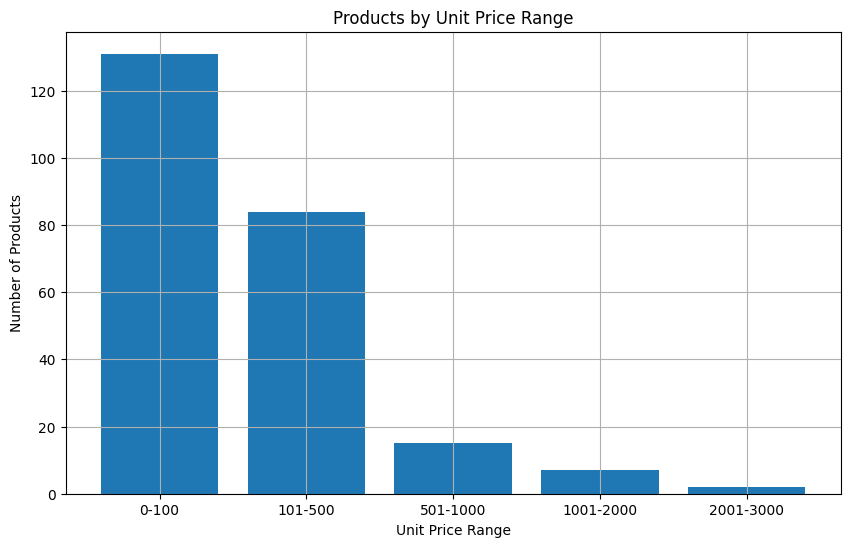

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("Online Sales Data.csv")

# Convert float columns to integer
df['Unit Price'] = df['Unit Price'].astype(int)
df['Total Revenue'] = df['Total Revenue'].astype(int)

# Encode categorical columns
encoder = LabelEncoder()

df['Product Category'] = encoder.fit_transform(df['Product Category'])
df['Product Name'] = encoder.fit_transform(df['Product Name'])
df['Region'] = encoder.fit_transform(df['Region'])
df['Payment Method'] = encoder.fit_transform(df['Payment Method'])

# Create ranges for Unit Price
bins = [0, 100, 500, 1000, 2000, 3000]
labels = ['0-100', '101-500', '501-1000', '1001-2000', '2001-3000']

df['Price Range'] = pd.cut(df['Unit Price'], bins=bins, labels=labels)

# Count products in each range
range_count = df['Price Range'].value_counts().sort_index()

# Plot graph
plt.figure(figsize=(10, 6))

plt.bar(range_count.index.astype(str), range_count.values)

# Grid lines
plt.grid(True)

# Labels and title
plt.xlabel("Unit Price Range")
plt.ylabel("Number of Products")
plt.title("Products by Unit Price Range")

# Show graph
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("Online Sales Data.csv")

# Count each category
category_count = df['Product Category'].value_counts()

print(category_count)

Product Category
Electronics        40
Home Appliances    40
Clothing           40
Books              40
Beauty Products    40
Sports             40
Name: count, dtype: int64


C:\Users\bhavy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


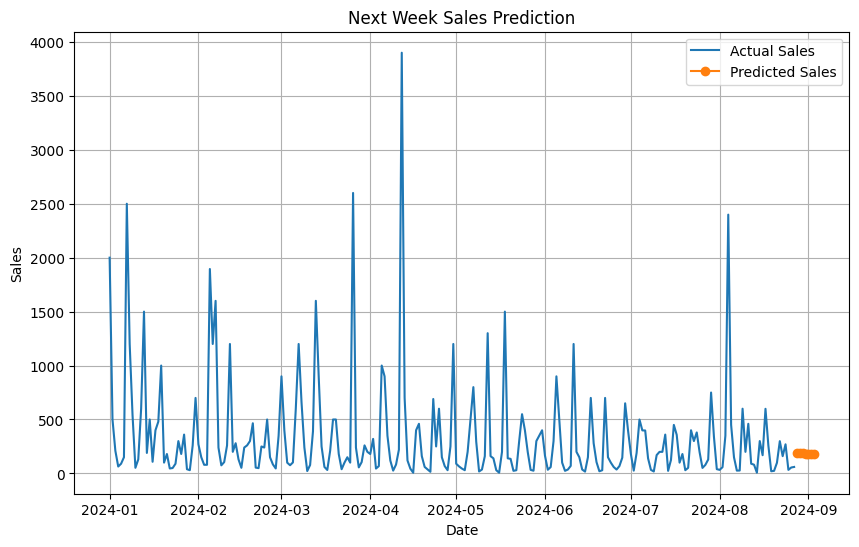

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Load dataset
df = pd.read_csv("Online Sales Data.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Group sales by date
daily_sales = df.groupby('Date')['Total Revenue'].sum().reset_index()

# Create day numbers
daily_sales['Day'] = np.arange(len(daily_sales))

# Features and target
X = daily_sales[['Day']]
y = daily_sales['Total Revenue']

# Train model
model = LinearRegression()
model.fit(X, y)

# Predict next 7 days
future_days = np.arange(len(daily_sales), len(daily_sales) + 7).reshape(-1, 1)
predictions = model.predict(future_days)

# Future dates
future_dates = pd.date_range(
    start=daily_sales['Date'].max() + pd.Timedelta(days=1),
    periods=7
)

# Plot graph
plt.figure(figsize=(10, 6))

plt.plot(daily_sales['Date'], y, label='Actual Sales')
plt.plot(future_dates, predictions, marker='o', label='Predicted Sales')

plt.grid(True)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Next Week Sales Prediction")
plt.legend()

plt.show()

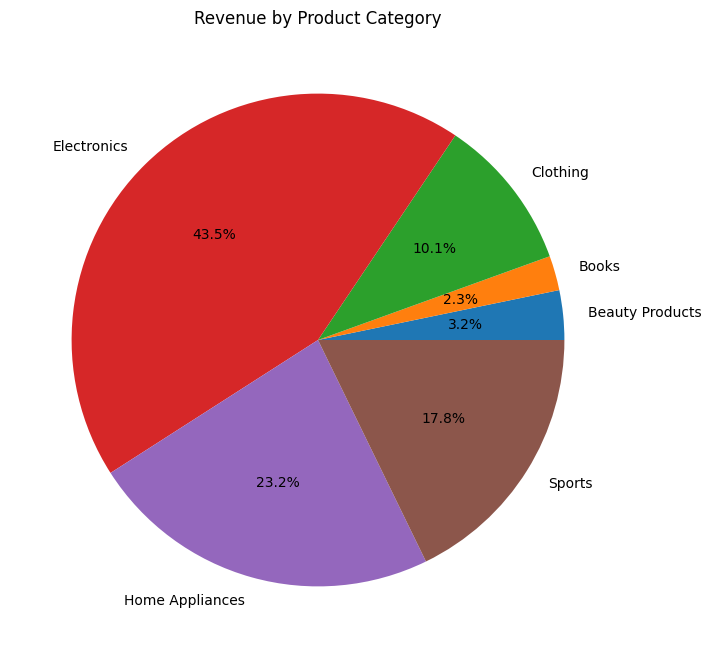

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('Online Sales Data.csv')

# Convert Total Revenue to integer
df['Total Revenue'] = df['Total Revenue'].astype(int)

# Group by Product Category
category_sales = df.groupby('Product Category')['Total Revenue'].sum()

# Data for pie chart
data = category_sales.values
labels = category_sales.index

# Create pie chart
plt.figure(figsize=(8,8))

plt.pie(
    data,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title('Revenue by Product Category')
plt.show()